This disables autoscroll in Jupyter notebooks, it is easier to look at the figures this way.

In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

Importing libraries and the geometric layout of the simulation.

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import json

In [3]:
import os
import sys

# Only move up if we are not already at the project root geometry.py is located
if not os.path.exists('geometry.py'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from geometry import City

Creating a sample config for the geometry class.

In [4]:
conf = {
    "n": 40,
    "m": 40,
    "num_taxis": 3,
    "request_rate": 1,
    "log": False,
    "max_time": 1000,
    "length": 1000,
    "hard_limit": 10,
    "show_map_labels": False,
    "behaviour": "stay",
    "initial_conditions": "home",
    "show_pending": False,
    "show_plot": True,
    "matching": "baseline_random_user_nearest_taxi",
    "request_origin_distributions": [
        {
            "location": [
                5,
                5
            ],
            "strength": 1,
            "sigma": 5
        }
    ]
}

Loading geometry specifications from configuratino JSON file.

In [5]:
geom_specs = [json.loads(e.strip('\n')) for e in open('configs/geom_specification_compact.json').readlines()]

Creating request origin and destination coordinates and plotting their distributions.

In [6]:
def plot_geoms(ind, num=int(5e5)):
    if 'request_destination_distributions' in conf:
        del conf['request_destination_distributions']
    if 'request_origin_distributions' in conf:
        del conf['request_origin_distributions']
    if ind > 9:
        conf["n"] = 100
        conf["m"] = 100
    else:
        conf["n"] = 40
        conf["m"] = 40
    conf.update(geom_specs[ind])
    c = City(**conf)
    o = []
    d = []
    inds = []
    for i in range(num):
        ox, oy, dx, dy = c.create_one_request_coord()
        o.append((ox, oy))
        d.append((dx, dy))
    o = np.array(o)
    d = np.array(d)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5.5))

    # Helper function to filter out non-serializable objects for display
    def make_serializable(distributions):
        """Remove non-JSON-serializable objects from distributions"""
        filtered = []
        for dist in distributions:
            # Create a copy and remove cdf_inv if it exists
            dist_copy = {k: v for k, v in dist.items() if k != 'cdf_inv'}
            # Truncate long arrays for display
            if 'x' in dist_copy and len(dist_copy['x']) > 10:
                dist_copy['x'] = f"[array of {len(dist_copy['x'])} values]"
            if 'y' in dist_copy and len(dist_copy['y']) > 10:
                dist_copy['y'] = f"[array of {len(dist_copy['y'])} values]"
            filtered.append(dist_copy)
        return filtered

    if 'request_destination_distributions' in geom_specs[ind]:
        origins_display = make_serializable(geom_specs[ind]['request_origin_distributions'])
        destinations_display = make_serializable(geom_specs[ind]['request_destination_distributions'])
        fig.suptitle('Geometry ' + str(ind) + '\n' + json.dumps(origins_display) + '\n' +
                     json.dumps(destinations_display) + '\n\n')
    else:
        origins_display = make_serializable(geom_specs[ind]['request_origin_distributions'])
        fig.suptitle('Geometry ' + str(ind) + '\n' + json.dumps(origins_display) + '\n\n')

    ax[0].hist2d(o[:, 0], o[:, 1], bins=(conf['n'], conf['m']), range=((0, conf['n']), (0, conf['m'])), cmap='YlOrRd')
    ax[0].set_title('Origins')
    ax[1].hist2d(d[:, 0], d[:, 1], bins=(conf['n'], conf['m']), range=((0, conf['n']), (0, conf['m'])), cmap='YlOrRd')
    ax[1].set_title('Destinations')
    plt.subplots_adjust(top=0.8)
    plt.savefig('figs/geom' + str(ind) + '.png')

Making the plots.

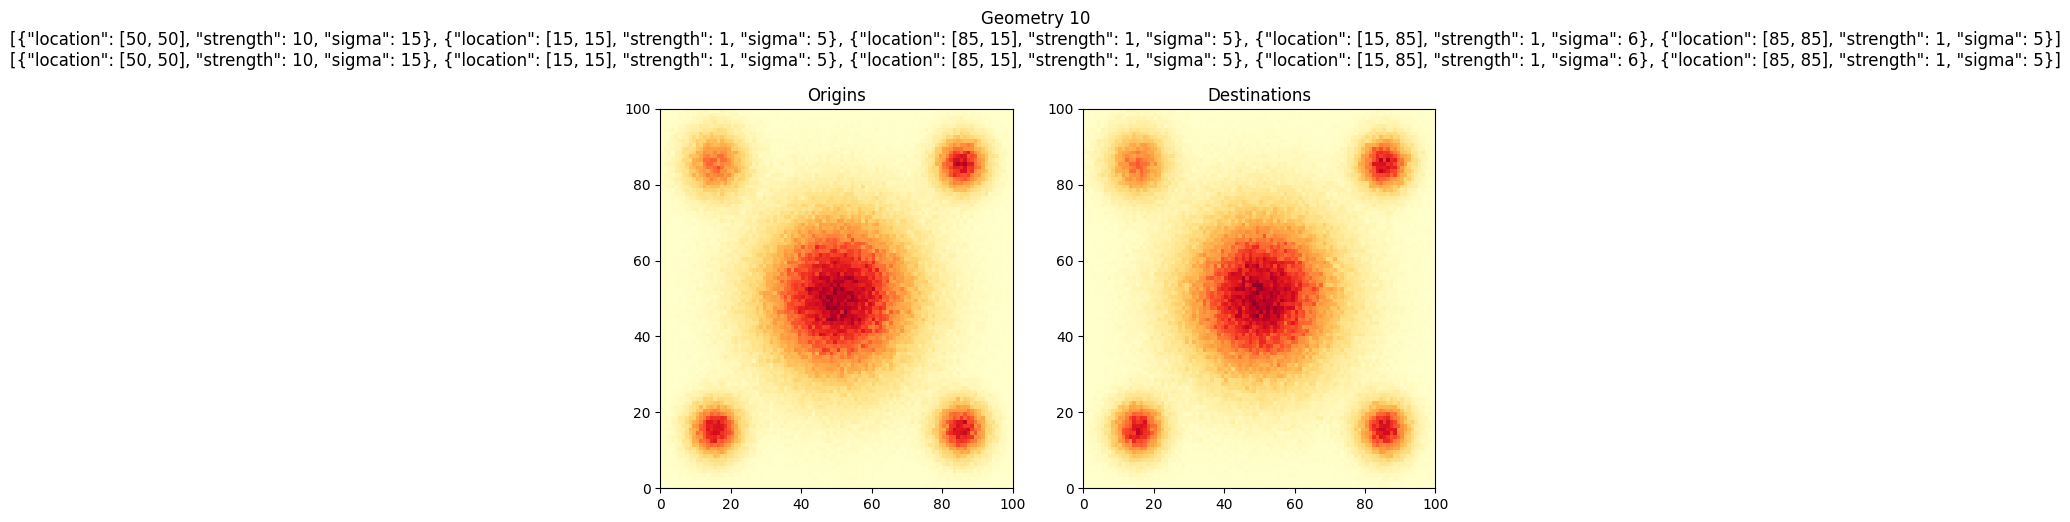

In [7]:
plot_geoms(10)

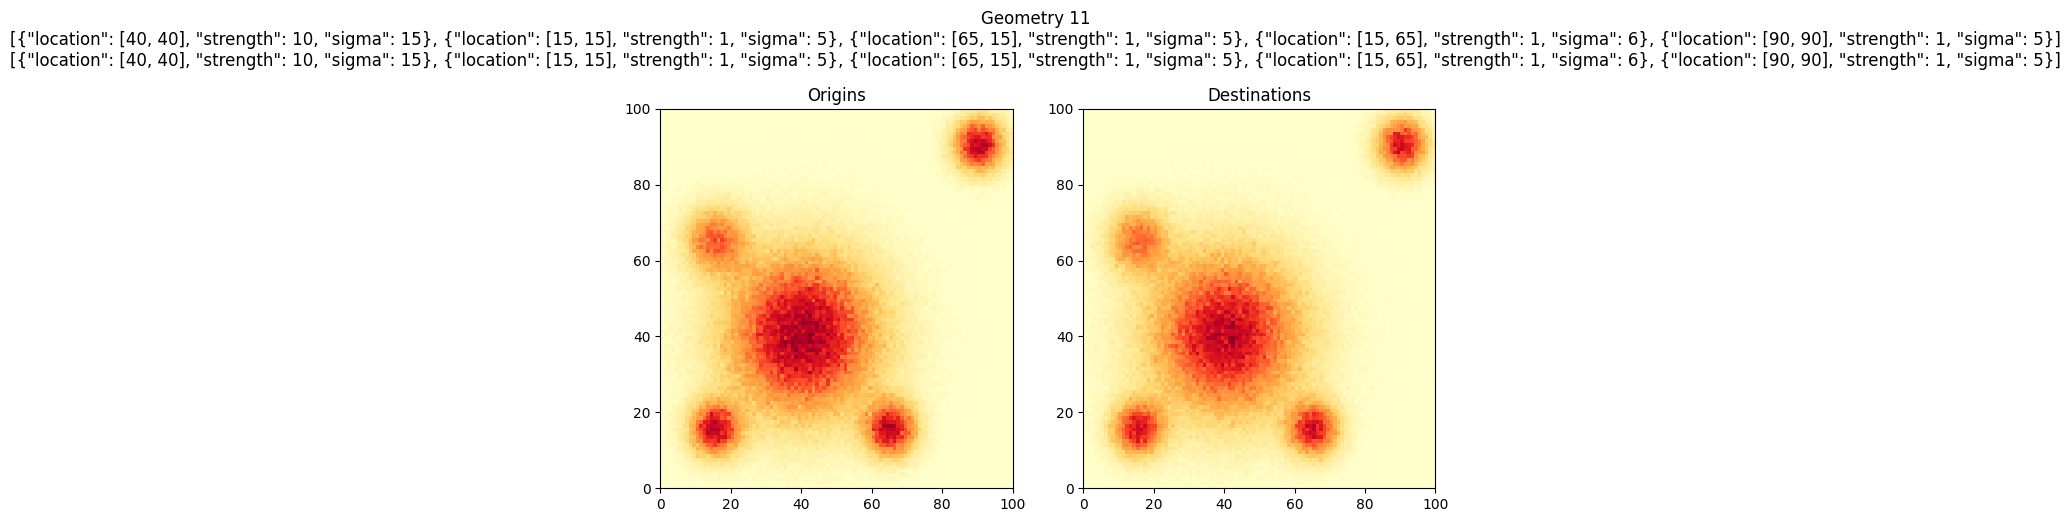

In [8]:
plot_geoms(11)

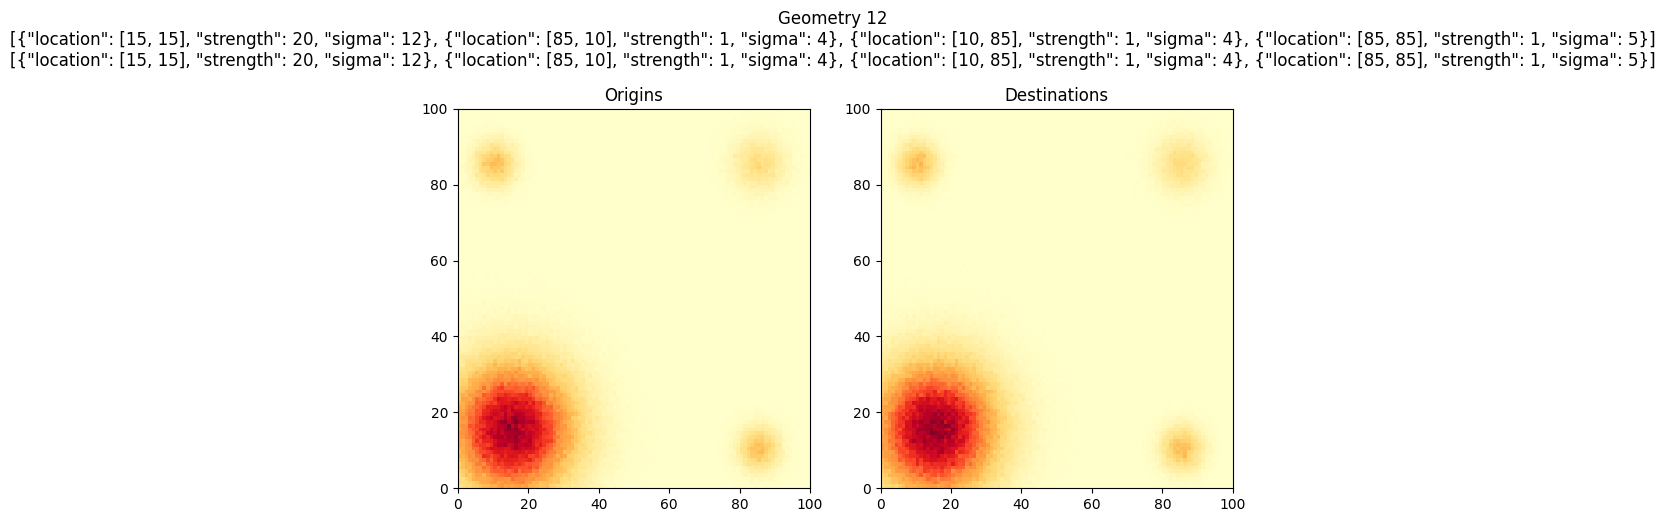

In [9]:
plot_geoms(12)

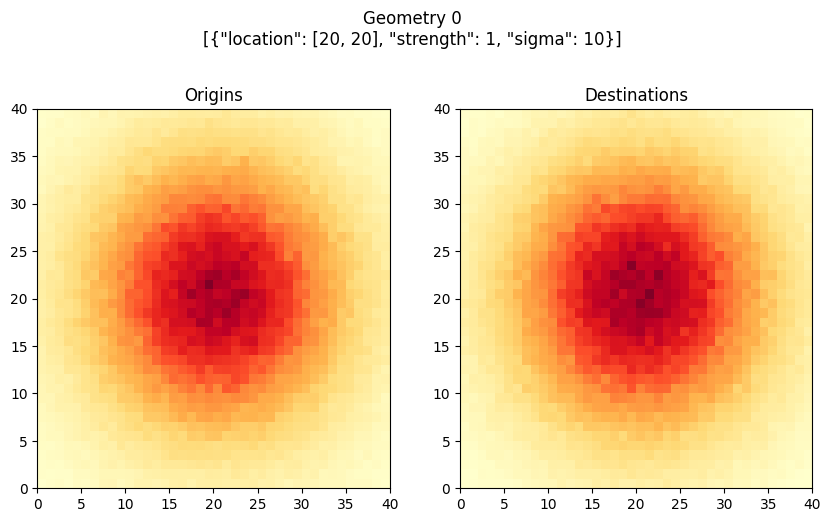

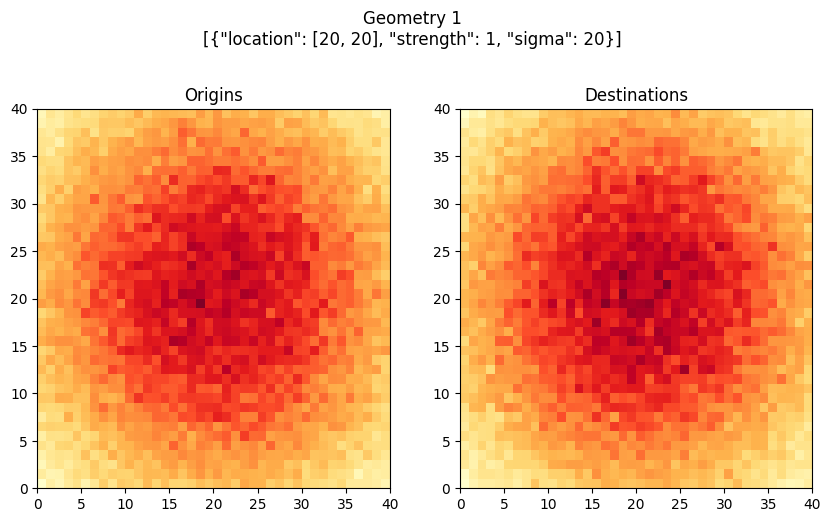

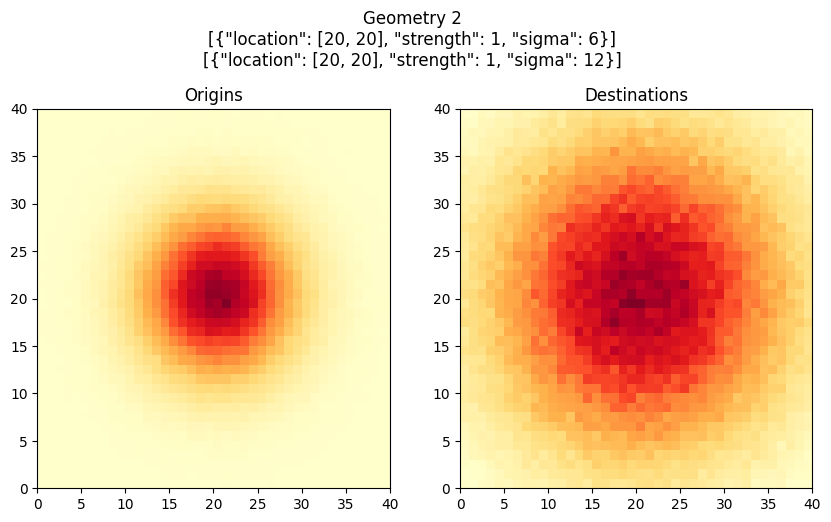

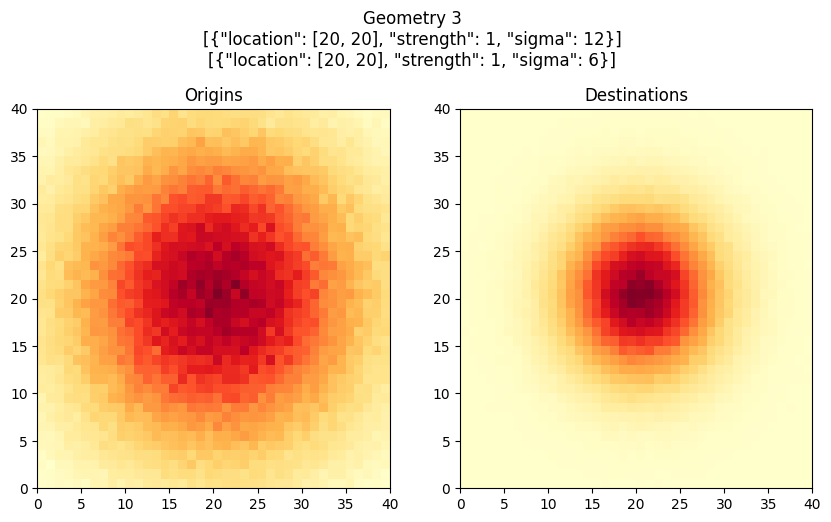

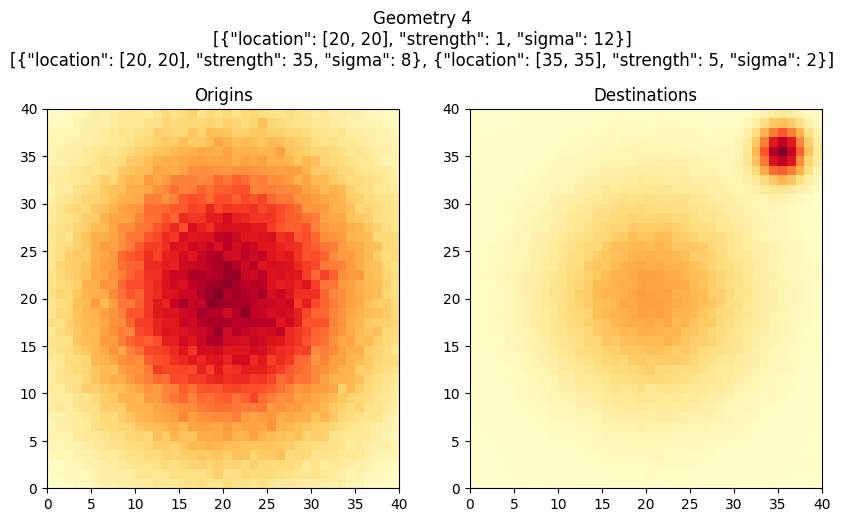

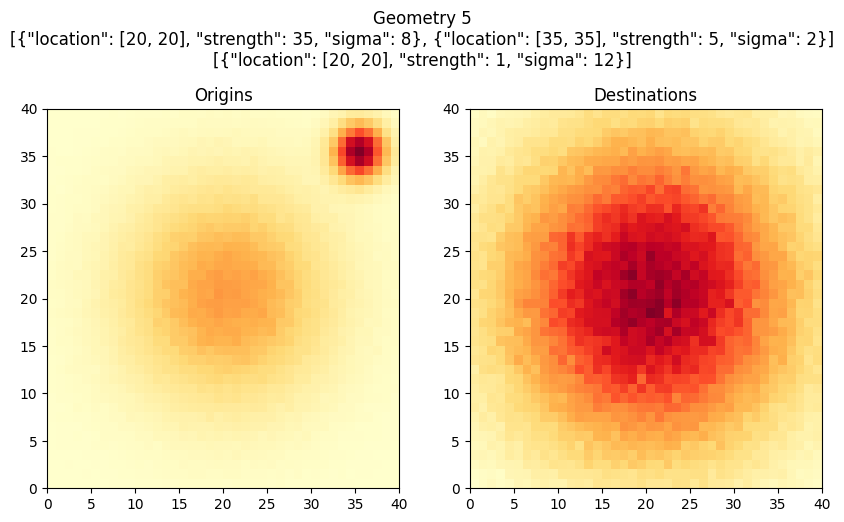

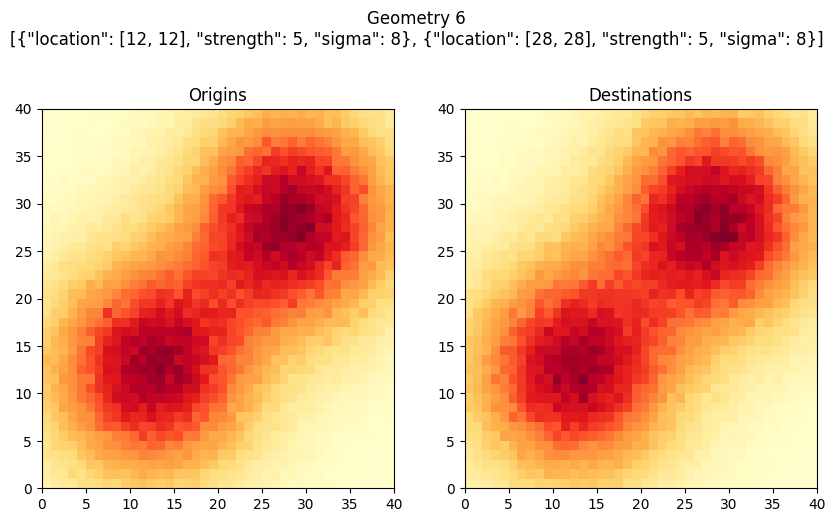

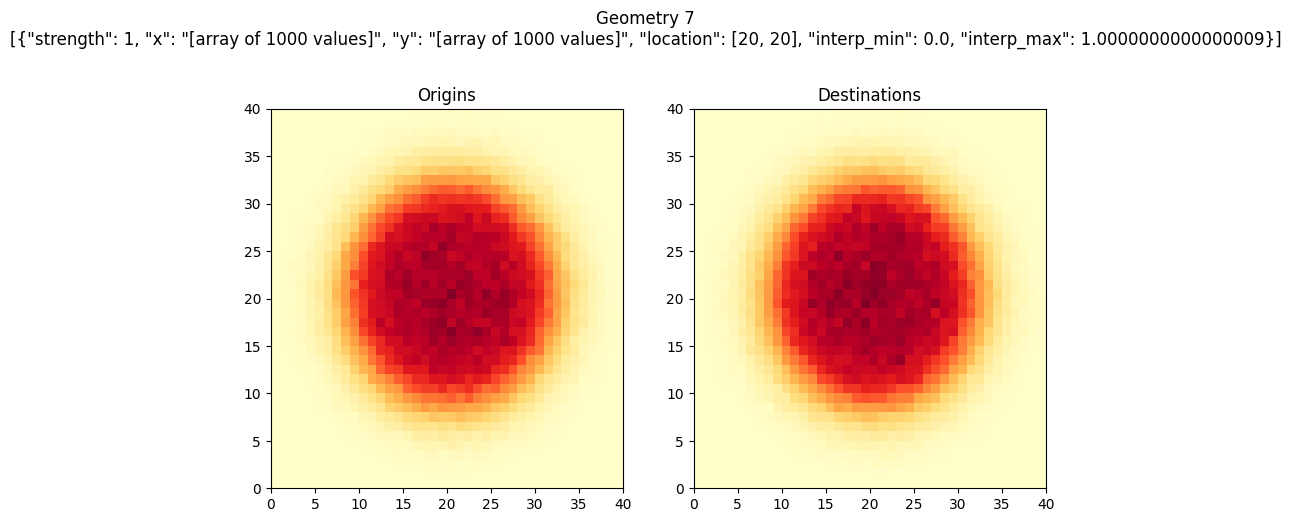

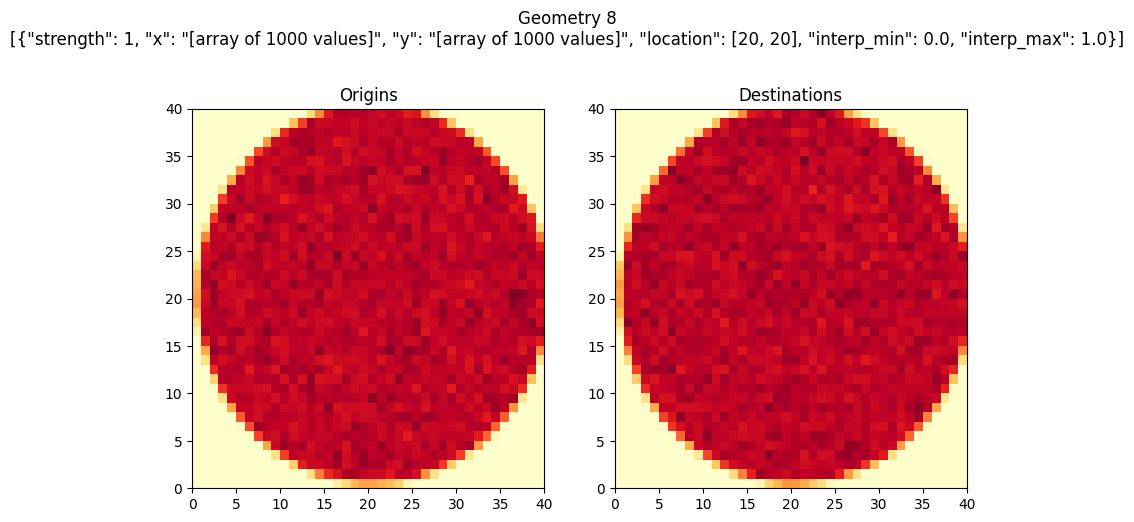

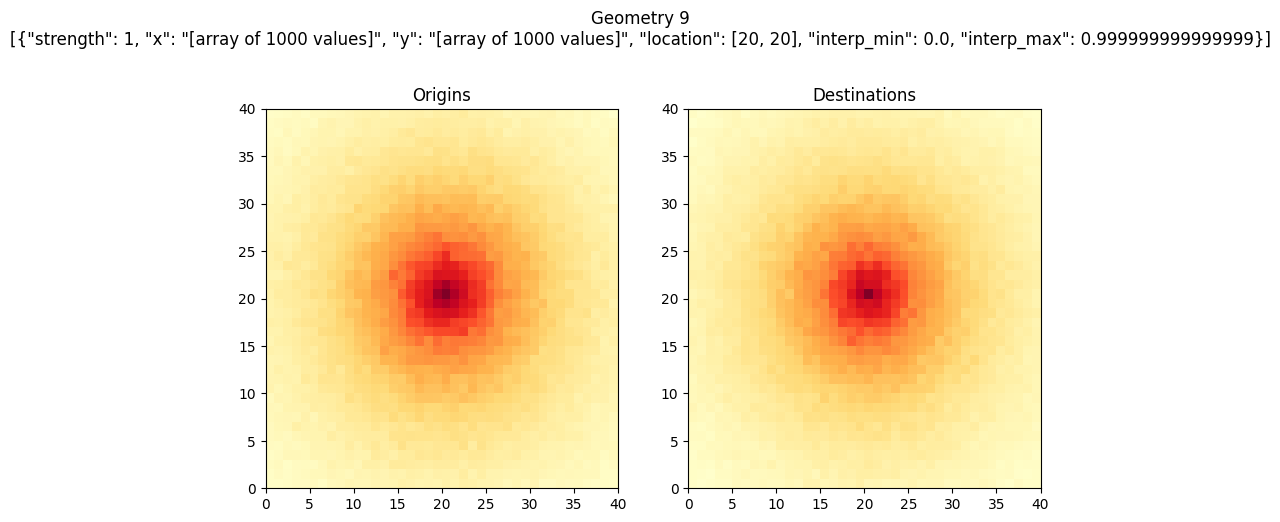

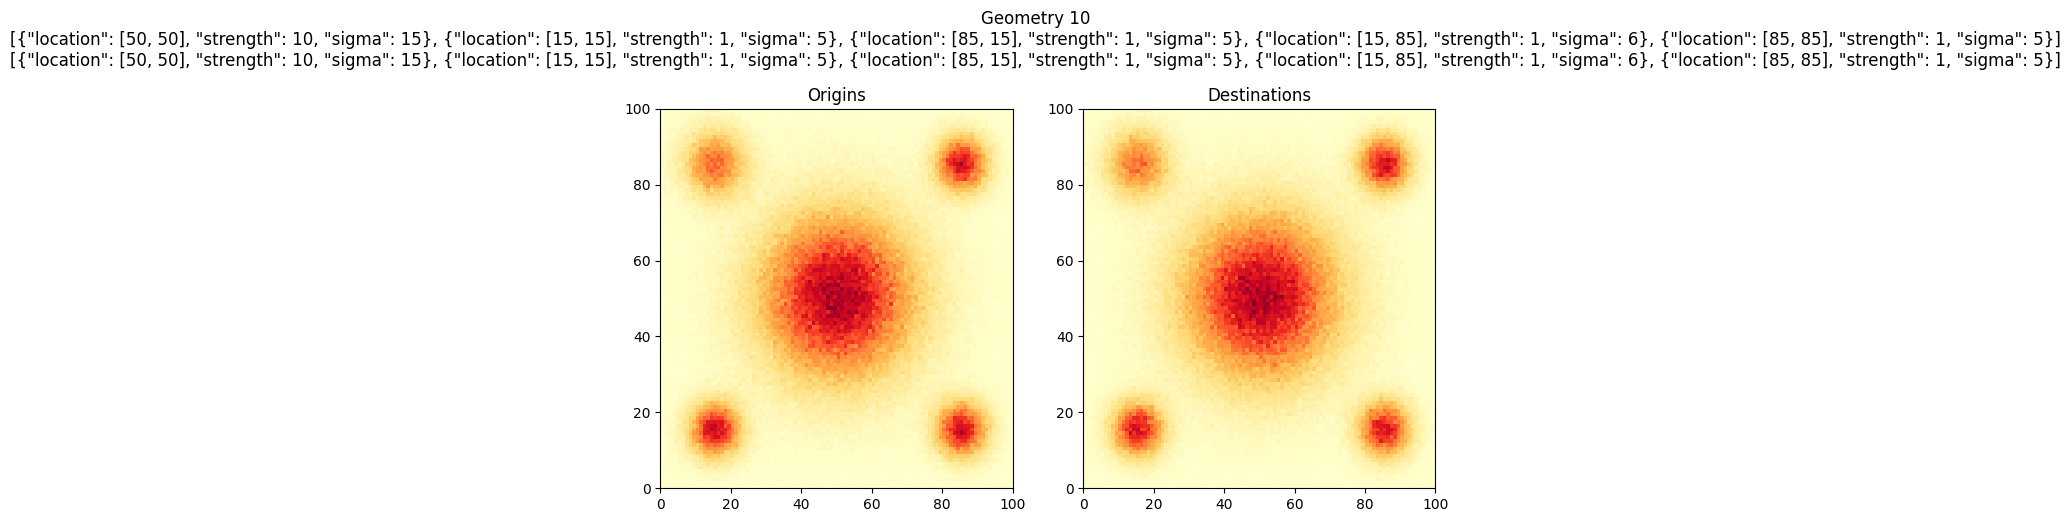

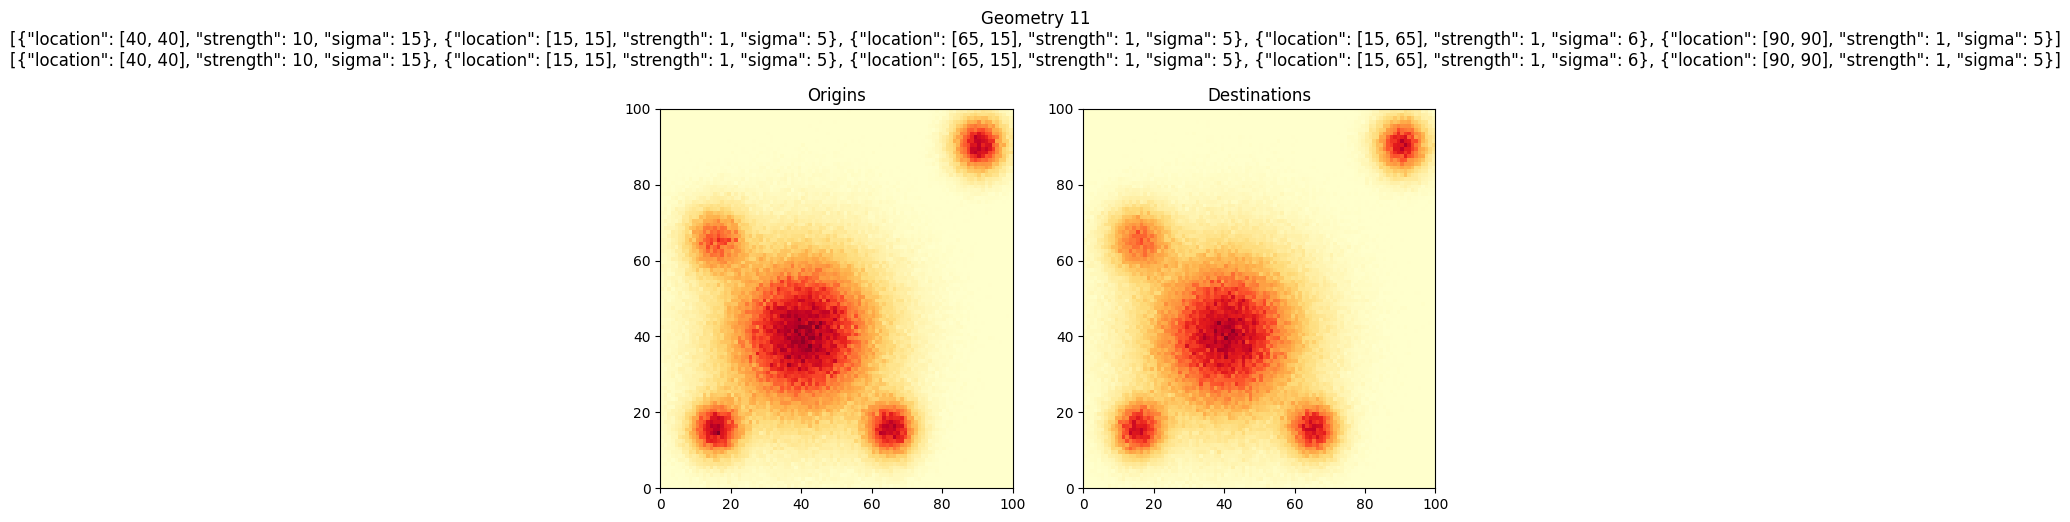

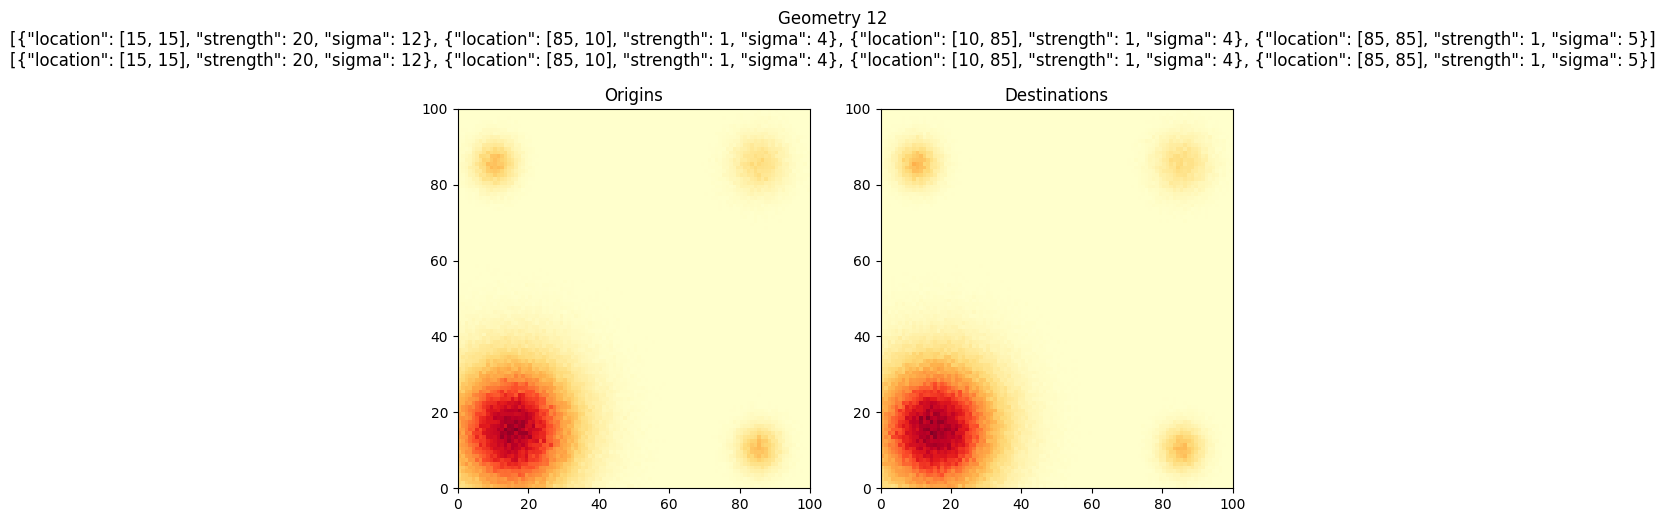

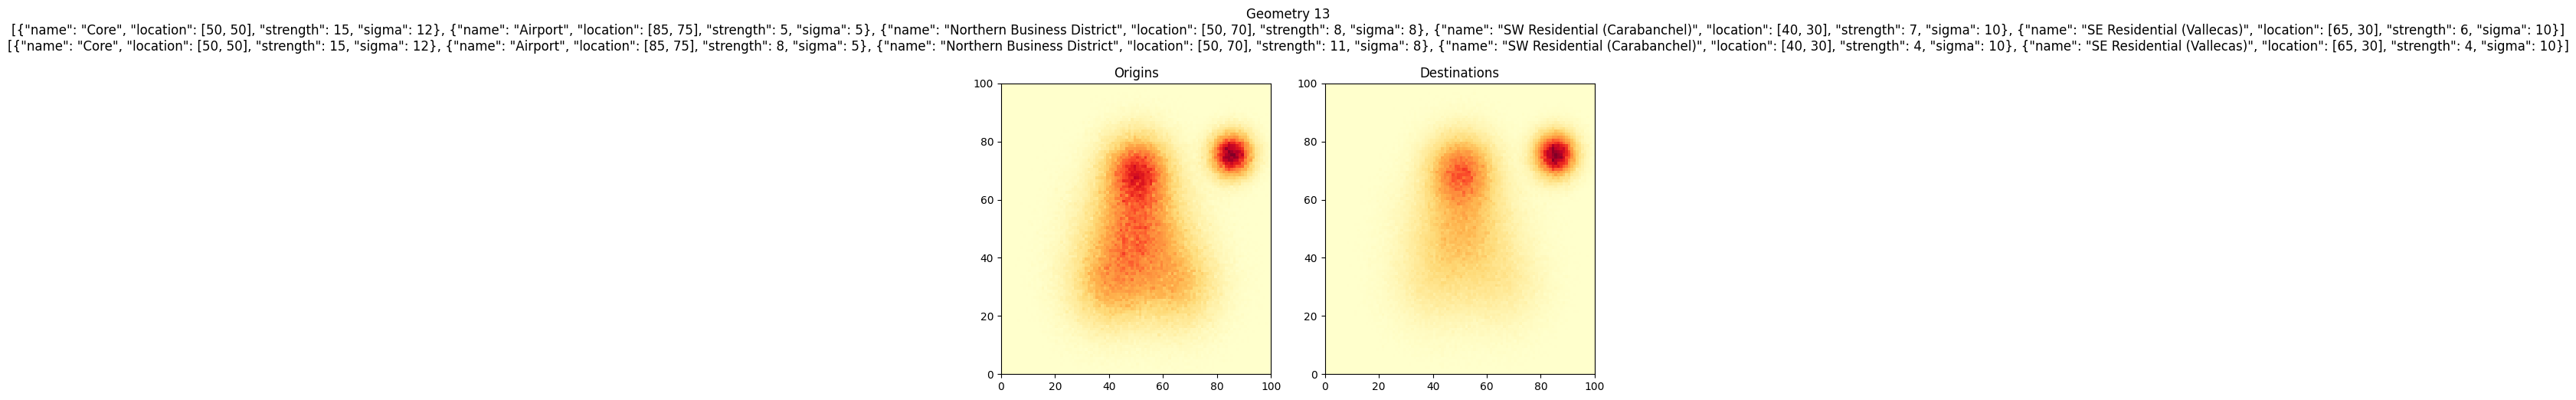

In [10]:
for i in range(len(geom_specs)):
    plot_geoms(i)